**Loss function**

$$L(\beta) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

<img src="Equation%20by%20hand/PHOTO-2026-06-02-16-22-45.jpg" width="400" />

Derivative of loss function - chain rule or gradient 
    $$
    \frac{\partial L}{\partial \beta}=\frac{1}{n}\sum_{i=1}^n 2\left(\hat{y}_i-y_i\right)\cos(\beta x_i)\,x_i
    $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# True function for data generation (nonlinear, smooth)
def true_function(x):
    return np.sin(2.0 * x)

# Model prediction
def predict_model(x, beta):
    return np.sin(beta * x)

# General loss and gradient for any batch of data
def loss_and_gradient(beta, x_batch, y_batch):
    # Call predict_model() to generate predictions
    y_pred = predict_model(x_batch, beta)
    # Compute the prediction error (difference between predictions and ground truth)
    error = y_pred - y_batch
    # Compute the mean squared error (MSE) loss from the prediction error
    loss = np.mean(error**2)
    # Compute the gradient of the loss with respect to beta (dL/dbeta)
    # Hint: use np.mean() to compute the average gradient over the batch
    gradient_beta = np.mean(2 * error * np.cos(beta * x_batch) * x_batch)
    return loss, gradient_beta, y_pred

# Build a fixed dataset (streamed in mini-batches)
np.random.seed(130)
n_points = 120
x_data = np.linspace(-3.0, 3.0, n_points)
y_data = true_function(x_data)

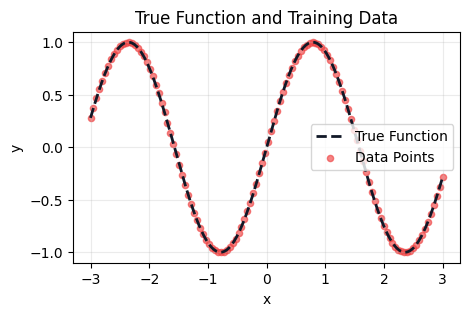

In [2]:
# Data visualization
x_plot = np.linspace(-3.0, 3.0, 800)
y_plot = true_function(x_plot)

plt.figure(figsize=(5, 3))
plt.plot(x_plot, y_plot, linestyle='--', linewidth=2, color='#111827', label='True Function')
plt.scatter(x_data, y_data, s=20, alpha=0.65, label='Data Points', color='#EF4444')

plt.xlabel('x')
plt.ylabel('y')
plt.title('True Function and Training Data')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

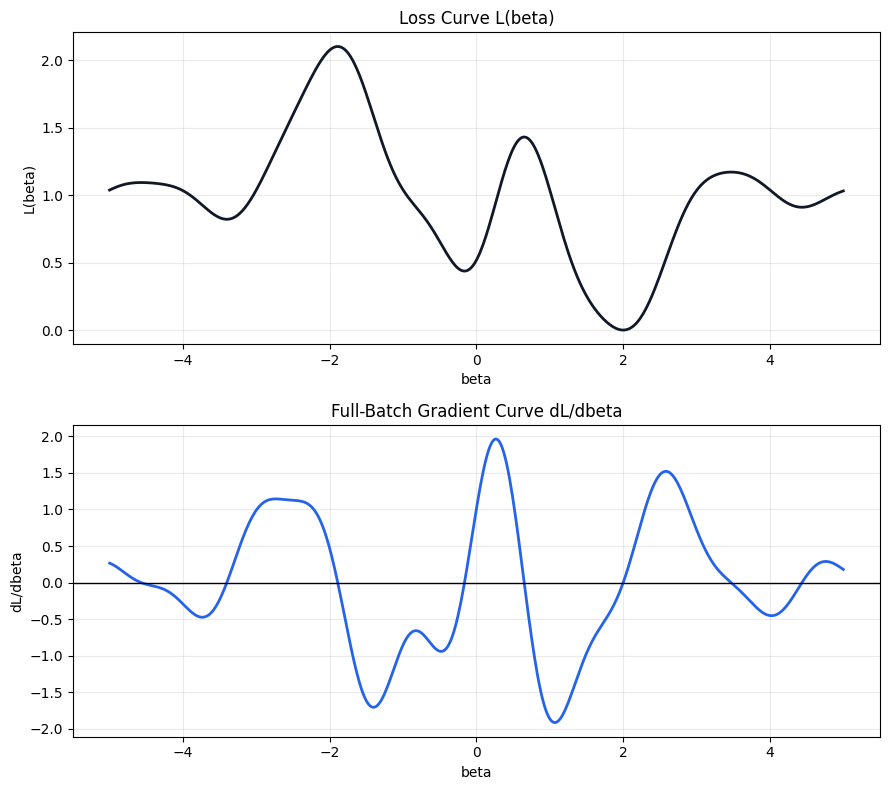

In [3]:
# Build loss and gradient curves on a grid of parameter values
beta_grid = np.linspace(-5.0, 5.0, 500)

full_loss_values = []
full_gradient_values = []

for beta_value in beta_grid:
    # Use loss_and_gradient() to compute loss and gradient over the full dataset (full-batch)
    full_loss, full_gradient, y_pred = loss_and_gradient(beta_value,x_data,y_data)
    full_loss_values.append(full_loss)
    full_gradient_values.append(full_gradient)

full_loss_values = np.array(full_loss_values)
full_gradient_values = np.array(full_gradient_values)

fig, axes = plt.subplots(2, 1, figsize=(9, 8))

# ---- Loss curve ----
axes[0].plot(beta_grid, full_loss_values, color='#111827', linewidth=2)
axes[0].set_title('Loss Curve L(beta)')
axes[0].set_xlabel('beta')
axes[0].set_ylabel('L(beta)')
axes[0].grid(alpha=0.25)

# ---- Gradient curve ----
axes[1].plot(beta_grid, full_gradient_values, color='#2563EB', linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Full-Batch Gradient Curve dL/dbeta')
axes[1].set_xlabel('beta')
axes[1].set_ylabel('dL/dbeta')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [4]:
def run_sgd_visual(lr=0.08, max_iter=12, beta_init=-1.5, batch_size=1, seed=7):
    if batch_size < 1:
        raise ValueError('batch_size must be at least 1.')
    if batch_size > len(x_data):
        raise ValueError('batch_size cannot exceed the number of data points.')

    local_rng = np.random.default_rng(seed)
    beta = float(beta_init)

    # History containers
    beta_history = [beta]
    full_loss_history = []
    batch_loss_history = []
    batch_gradient_history = []

    # Stream mini-batches by shuffling once per epoch
    order = np.arange(len(x_data))
    local_rng.shuffle(order)
    pointer = 0

    for step in range(max_iter):
        if pointer + batch_size > len(order):
            local_rng.shuffle(order)
            pointer = 0

        batch_indices = order[pointer:pointer + batch_size]
        pointer += batch_size

        x_batch = x_data[batch_indices]
        y_batch = y_data[batch_indices]

        # Compute batch and full-dataset quantities at current beta
        batch_loss, gradient_beta, _ = loss_and_gradient(beta, x_batch, y_batch)
        full_loss, _, _ = loss_and_gradient(beta, x_data, y_data)

        # Build mini-batch gradient curves on the same beta grid
        batch_gradient_values = []
        for beta_value in beta_grid:
            _, batch_gradient, _ = loss_and_gradient(beta_value, x_batch, y_batch)
            batch_gradient_values.append(batch_gradient)
        batch_gradient_values = np.array(batch_gradient_values)

        # SGD update
        # Hint: future beta = current beta - learing rate * gradient of beta
        beta_next = beta - (lr*gradient_beta)
        
        next_full_loss, _, _ = loss_and_gradient(beta_next, x_data, y_data)
        _, batch_gradient_after, _ = loss_and_gradient(beta_next, x_batch, y_batch)

        # Track metrics before applying update
        full_loss_history.append(full_loss)
        batch_loss_history.append(batch_loss)
        batch_gradient_history.append(np.abs(gradient_beta))

        # Adaptive path density: short steps stay smooth, long steps get extra points
        path_length = np.abs(beta_next - beta)
        path_spacing = 0.015
        min_path_points = 32
        max_path_points = 220
        n_path_points = int(np.clip(np.ceil(path_length / path_spacing) + 1, min_path_points, max_path_points))

        beta_path = np.linspace(beta, beta_next, n_path_points)
        batch_grad_path = np.array([loss_and_gradient(beta_value, x_batch, y_batch)[1] for beta_value in beta_path])
        loss_path = np.array([loss_and_gradient(beta_value, x_data, y_data)[0] for beta_value in beta_path])

        fig, axes = plt.subplots(1, 2, figsize=(9, 5))

        # Left: keep both fields, but show update path/points only for mini-batch
        ax_left = axes[0]
        ax_left.plot(
            beta_grid,
            full_gradient_values,
            color='#111827',
            linewidth=2,
            alpha=0.3,
            label='Full-batch gradient Curve (reference)'
        )
        ax_left.plot(beta_grid, batch_gradient_values, '--', color='#F59E0B', linewidth=2, label='Mini-batch gradient field')

        ax_left.scatter(beta_path, batch_grad_path, s=55, color='#FDB6AA', alpha=0.75, label='Path (mini)')
        ax_left.scatter(
            [beta],
            [gradient_beta],
            c='#2563EB',
            s=120,
            edgecolor='black',
            label='Before (mini)'
        )
        ax_left.scatter(
            [beta_next],
            [batch_gradient_after],
            c='#EF4444',
            s=120,
            edgecolor='black',
            label='After (mini)'
        )

        ax_left.axhline(0, color='black', linewidth=1)
        ax_left.set_title('Gradient Curve: Mini-Batch Update Path')
        ax_left.set_xlabel('beta')
        ax_left.set_ylabel('dL/dbeta')
        ax_left.grid(alpha=0.25)
        ax_left.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=True)

        # Right: Loss landscape with before/after and pink path only
        ax_right = axes[1]
        ax_right.plot(beta_grid, full_loss_values, color='black', alpha=0.65, linewidth=2, label='Loss landscape')
        ax_right.scatter(beta_path, loss_path, s=70, color='#FDB6AA', alpha=0.75, label='_nolegend_')
        ax_right.scatter([beta], [full_loss], c='#2563EB', s=130, edgecolor='black', label='_nolegend_')
        ax_right.scatter([beta_next], [next_full_loss], c='#EF4444', s=130, edgecolor='black', label='_nolegend_')
        ax_right.set_title('Loss Curve: Before/After + Pink Path')
        ax_right.set_xlabel('beta')
        ax_right.set_ylabel('L(beta)')
        ax_right.grid(alpha=0.25)
        ax_right.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1, frameon=True)

        fig.suptitle(
            f'SGD Iteration {step + 1}/{max_iter} | beta={beta:.3f} -> {beta_next:.3f} | lr={lr} | batch_size={batch_size}',
            fontsize=13
        )
        fig.tight_layout(rect=[0, 0.15, 1, 0.95])
        plt.show()

        # Apply update
        beta = beta_next
        beta_history.append(beta)

    return {
        'beta_history': np.array(beta_history),
        'full_loss_history': np.array(full_loss_history),
        'batch_loss_history': np.array(batch_loss_history),
        'batch_gradient_history': np.array(batch_gradient_history),
    }

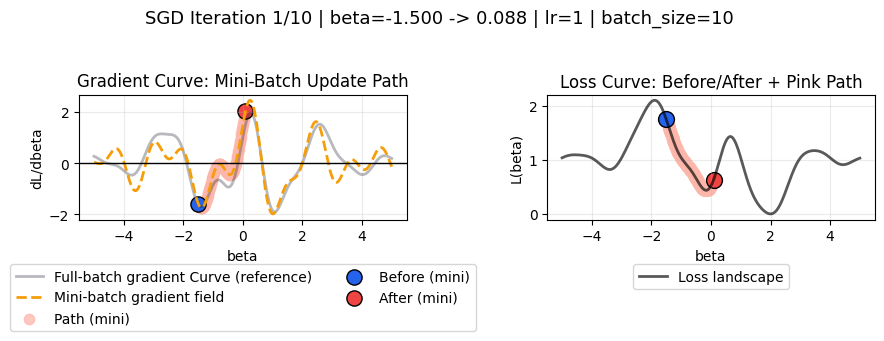

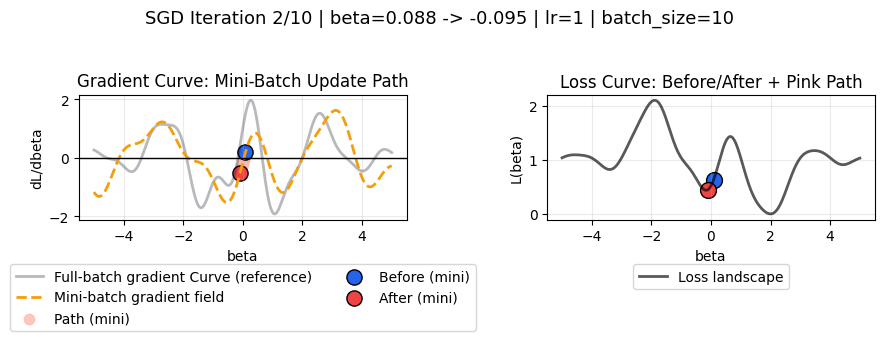

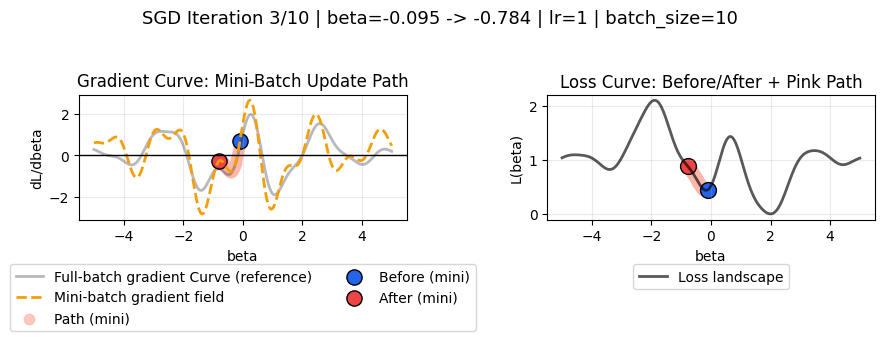

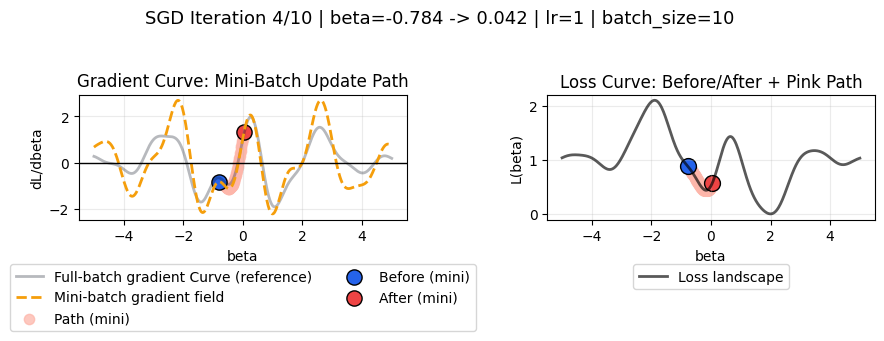

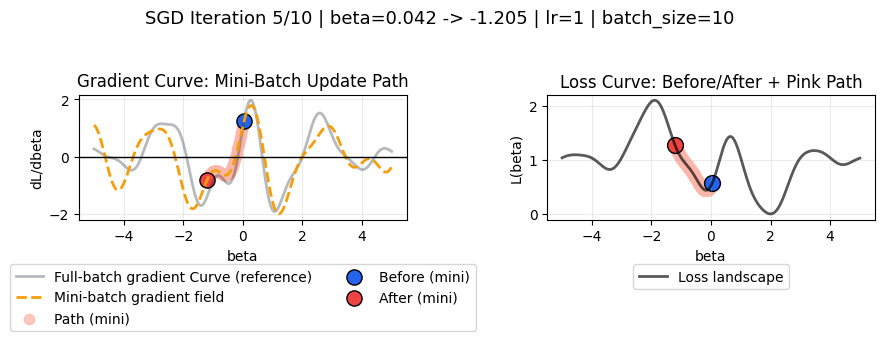

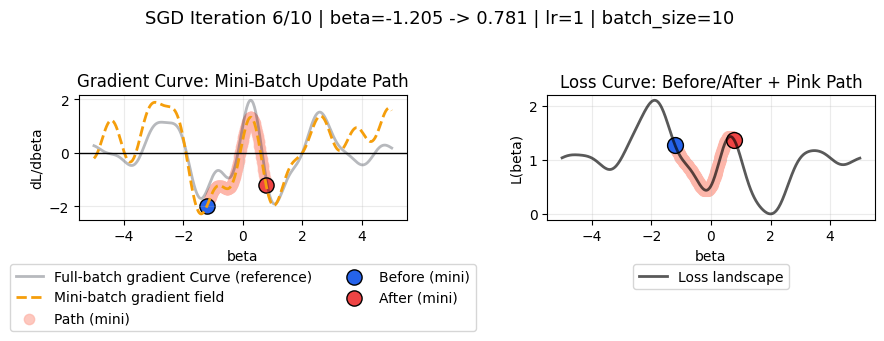

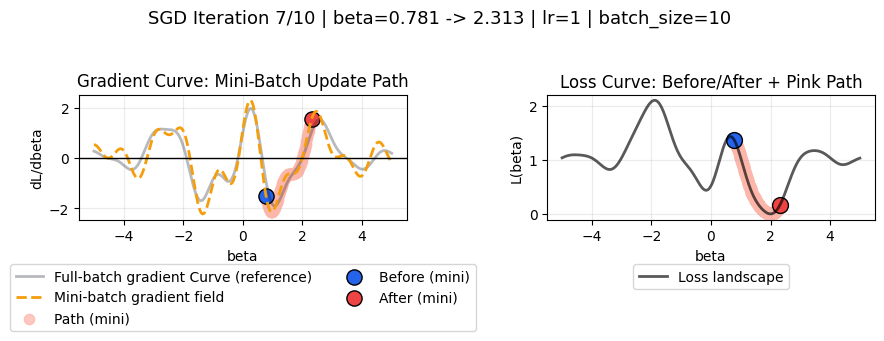

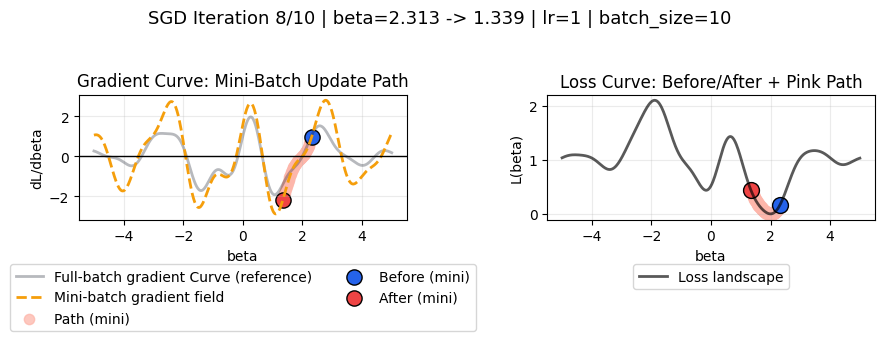

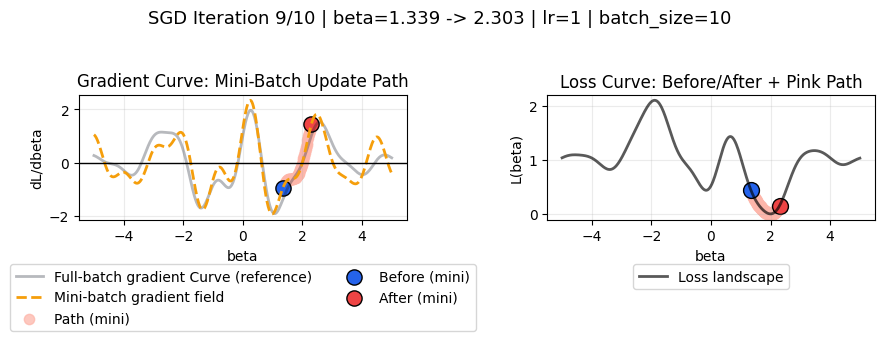

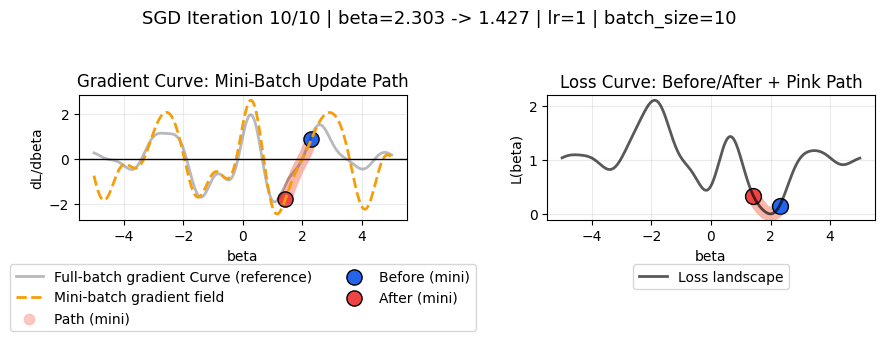

In [5]:
history = run_sgd_visual(lr=1, max_iter=10, beta_init=-1.5, batch_size=10, seed=7)